# 📊 KickProphet: Data Analysis

In questo notebook analizziamo il dataset processato `KICKSTARTER_TRAIN.csv` generato dallo script `preprocessing.py`. L'obiettivo è comprendere le distribuzioni delle feature e le loro correlazioni con il target (`successful` vs `failed`).

Questa analisi ci permette di valutare la **Model Readiness**: identificare bias, varianza e potenziali problemi di overfitting prima di addestrare il modello.

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configurazione Plot
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. CARICAMENTO
train_path = '../data/processed/KICKSTARTER_TRAIN.csv'
df = pd.read_csv(train_path)
print(f"📊 Dataset caricato: {df.shape}")

📊 Dataset caricato: (150491, 368)


## 🎯 1. Distribuzione del Target
**Cosa osserviamo:** Il bilanciamento tra progetti di successo (1) e falliti (0).
**Perché è importante:** Se il dataset è sbilanciato (es. 90% successo), il modello potrebbe sviluppare un **Bias** ottimistico e ignorare i segnali di fallimento. Un rapporto 60/40 o 50/50 è ideale per un addestramento robusto.

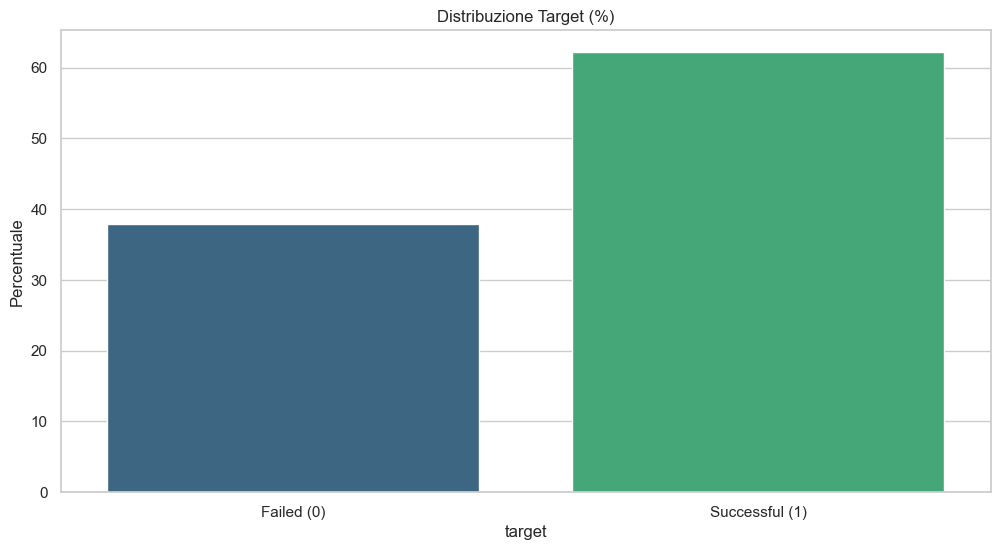

Bilanciamento:
target
1    62.167173
0    37.832827
Name: proportion, dtype: float64


In [83]:
target_counts = df['target'].value_counts(normalize=True) * 100
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, palette="viridis", legend=False)
plt.title("Distribuzione Target (%)")
plt.xticks([0, 1], ['Failed (0)', 'Successful (1)'])
plt.ylabel("Percentuale")
plt.show()

print(f"Bilanciamento:\n{target_counts}")

## 📈 2. Analisi delle Feature Numeriche
**Cosa osserviamo:** La forma delle distribuzioni (istogrammi) divise per target.
**Perché è importante:** Notiamo se le feature separano bene le classi. Se le curve di 'successo' e 'fallimento' sono quasi sovrapposte, la feature ha poco potere predittivo. FEATURE LOG: L'uso del logaritmo (es. `goal_usd_log`) serve a normalizzare variabili con code lunghe, riducendo l'impatto dei valori estremi sul modello.

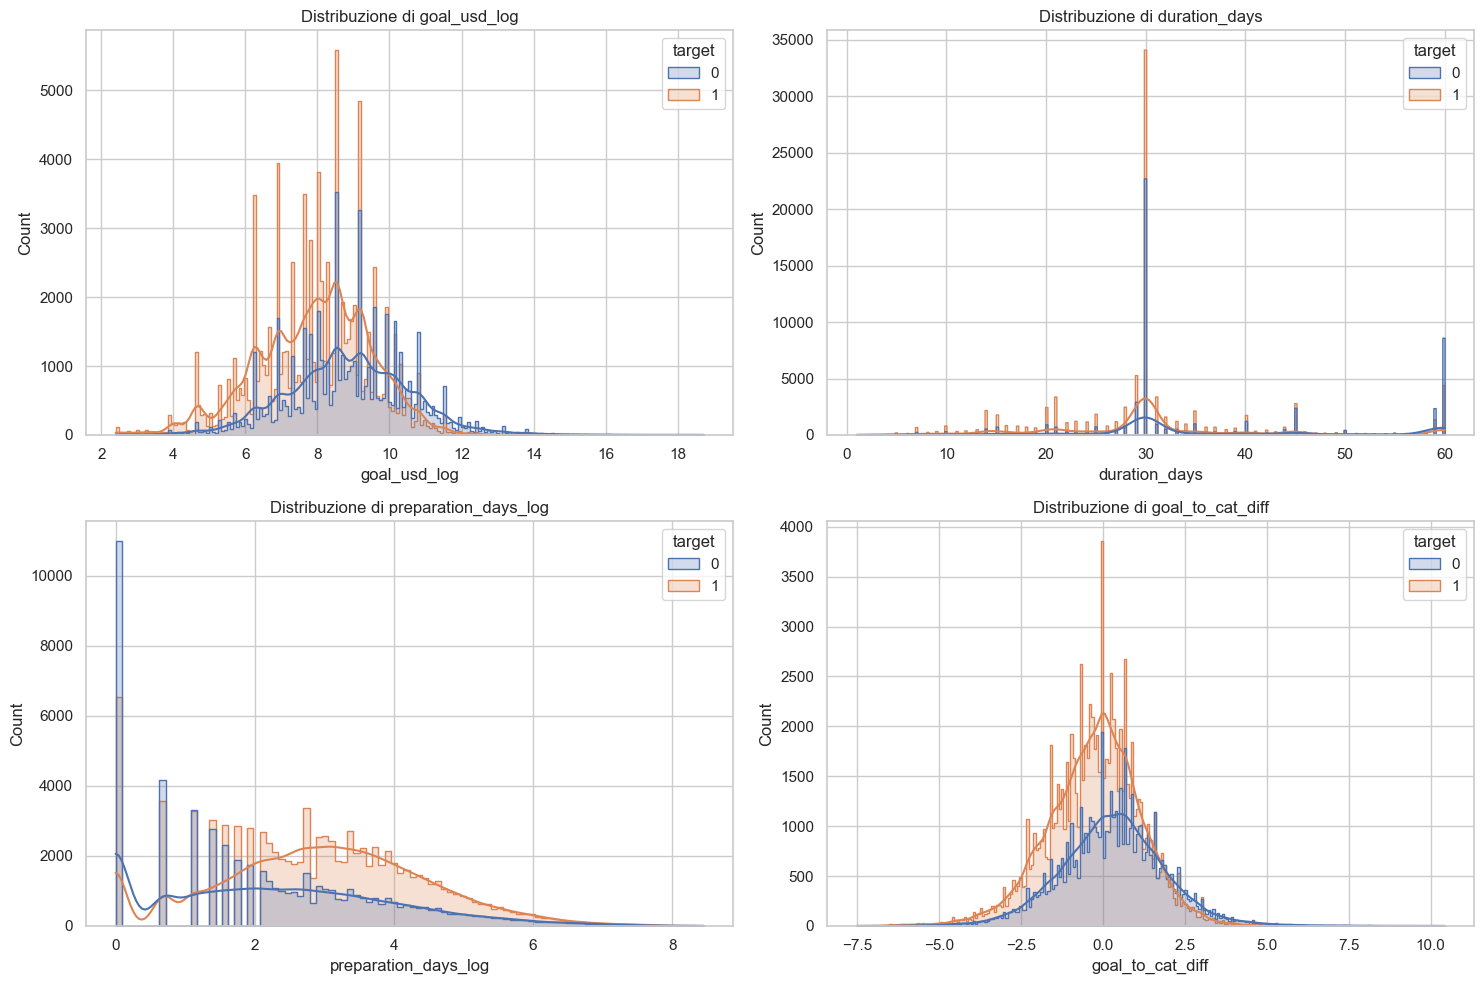

In [84]:
key_cols = ['goal_usd_log', 'duration_days', 'preparation_days_log', 'goal_to_cat_diff']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    if col in df.columns:
        sns.histplot(df, x=col, hue="target", kde=True, ax=axes[i], element="step")
        axes[i].set_title(f"Distribuzione di {col}")

plt.tight_layout()
plt.show()

## 🚫 3. Analisi degli Outlier
**Cosa osserviamo:** I punti al di fuori dei baffi del boxplot sono potenziali outlier (valori estremi).
**Perché è importante:** Troppi outlier possono aumentare la **Varianza** del modello, rendendolo instabile (il modello cerca di imparare da casi rari invece che dalla tendenza generale). In KickProphet, molti outlier nel goal sono filtrati o log-trasformati per mitigare questo problema.

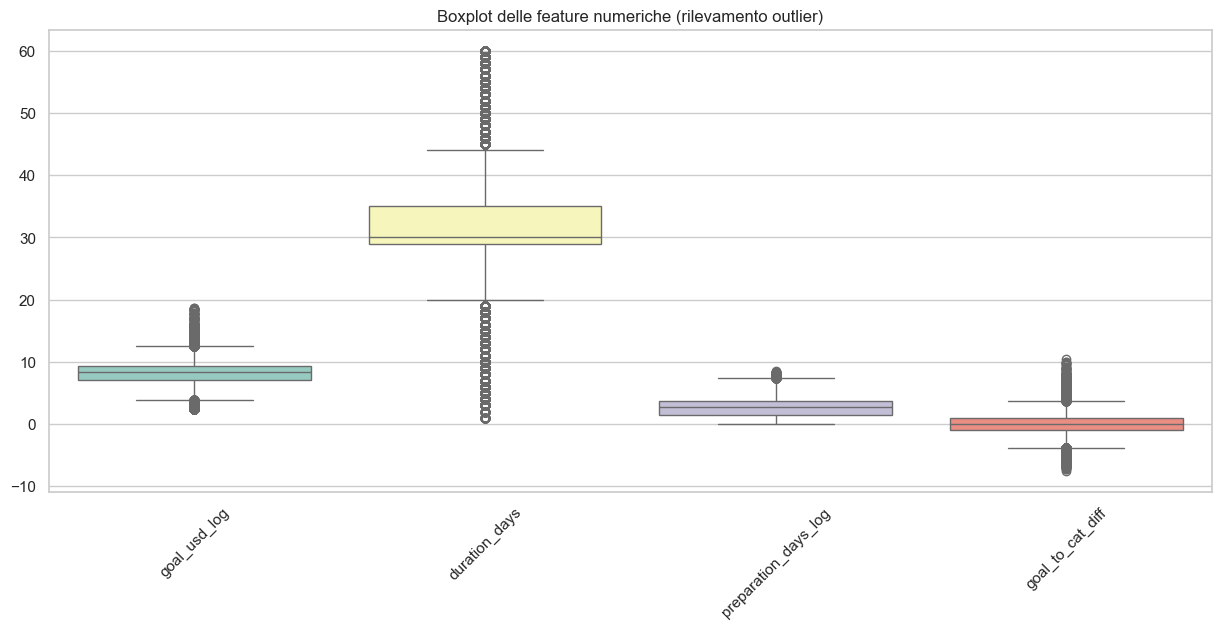

In [85]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[[c for c in key_cols if c in df.columns]], palette="Set3")
plt.title("Boxplot delle feature numeriche (rilevamento outlier)")
plt.xticks(rotation=45)
plt.show()

## ⚡ 4. Verifica Multicollinearità
**Cosa osserviamo:** La correlazione tra le variabili indipendenti.
**Perché è importante:** Se due variabili sono troppo correlate tra loro (> 0.8), portano la stessa informazione. Questo può confondere i modelli lineari (Underfitting o instabilità dei coefficienti). Se troviamo alte correlazioni, potremmo decidere di eliminare una delle due variabili ridondanti.

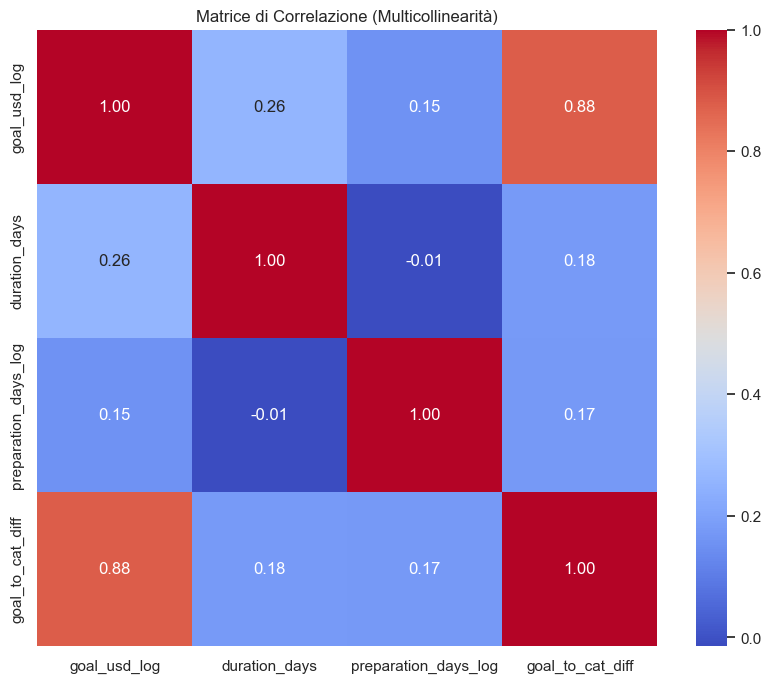

In [86]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[[c for c in key_cols if c in df.columns]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice di Correlazione (Multicollinearità)")
plt.show()

## 🏷️ 5. Analisi delle Categorie (Bias Check)
**Cosa osserviamo:** Quanto il successo varia a seconda della categoria del progetto.
**Perché è importante:** Alcune categorie (es. Comics, Dance) hanno tassi di successo storici molto più alti di altre (es. Technology). Questo ci dice che la categoria è un forte predittore, ma anche che il modello potrebbe essere **biased** verso certe categorie se non bilanciamo correttamente l'input.

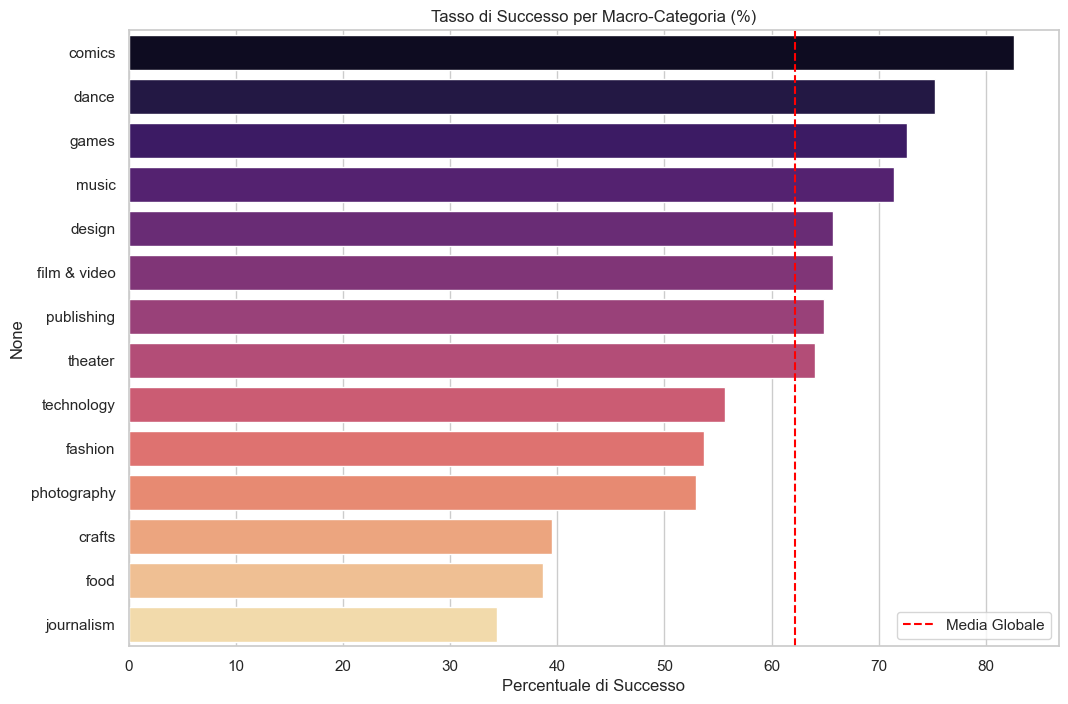

In [87]:
cat_cols = [c for c in df.columns if c.startswith('main_category_')]
if cat_cols:
    cat_success = {}
    for col in cat_cols:
        cat_name = col.replace('main_category_', '')
        success_rate = df[df[col] == 1]['target'].mean() * 100
        cat_success[cat_name] = success_rate
    
    cat_df = pd.Series(cat_success).sort_values(ascending=False)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=cat_df.values, y=cat_df.index, hue=cat_df.index, palette="magma", legend=False)
    plt.axvline(x=df['target'].mean()*100, color='red', linestyle='--', label='Media Globale')
    plt.title("Tasso di Successo per Macro-Categoria (%)")
    plt.xlabel("Percentuale di Successo")
    plt.legend()
    plt.show()

## 🎬 6. Analisi della Feature 'has_video'
**Cosa osserviamo:** Il tasso di successo basato sulla presenza di un video.
**Perché è importante:** I progetti con video tendono a mostrare una maggiore cura e professionalità, influenzando positivamente la fiducia dei backer.

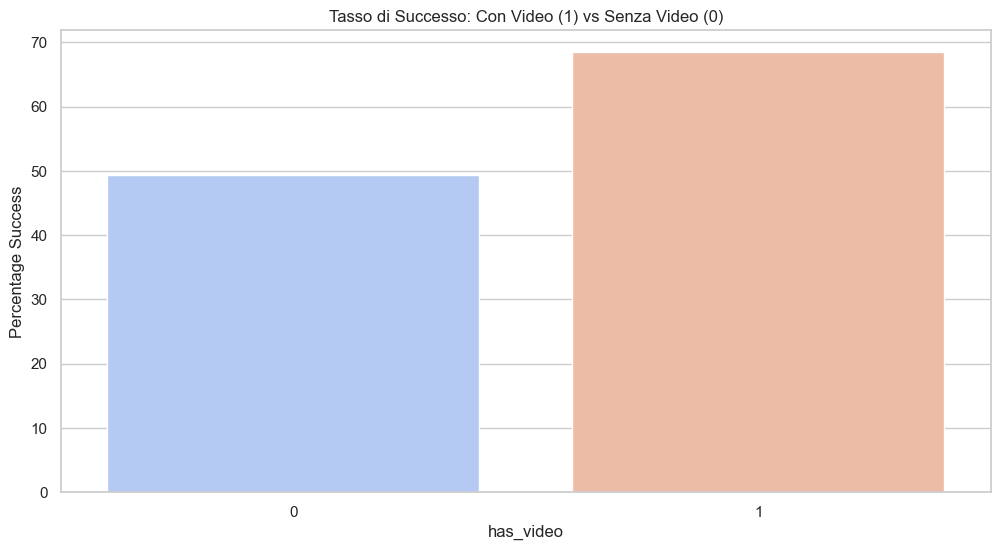

Success Rate per Video:
has_video
0    49.266773
1    68.478605
Name: target, dtype: float64


In [88]:
if 'has_video' in df.columns:
    video_success = df.groupby('has_video')['target'].mean() * 100
    sns.barplot(x=video_success.index, y=video_success.values, hue=video_success.index, palette="coolwarm", legend=False)
    plt.title("Tasso di Successo: Con Video (1) vs Senza Video (0)")
    plt.ylabel("Percentage Success")
    plt.show()
    
    print(f"Success Rate per Video:\n{video_success}")

## ⚖️ 7. Analisi del Goal Relativo (Ambizione)
**Cosa osserviamo:** Il successo del progetto in base a quanto il suo budget è sopra/sotto la media della sua categoria.
**Perché è importante:** Questa feature (`goal_to_cat_diff`) normalizza l'ambizione. Vedremo se i progetti che chiedono molto più della media della loro categoria tendono a fallire più spesso, indipendentemente dalla categoria stessa.

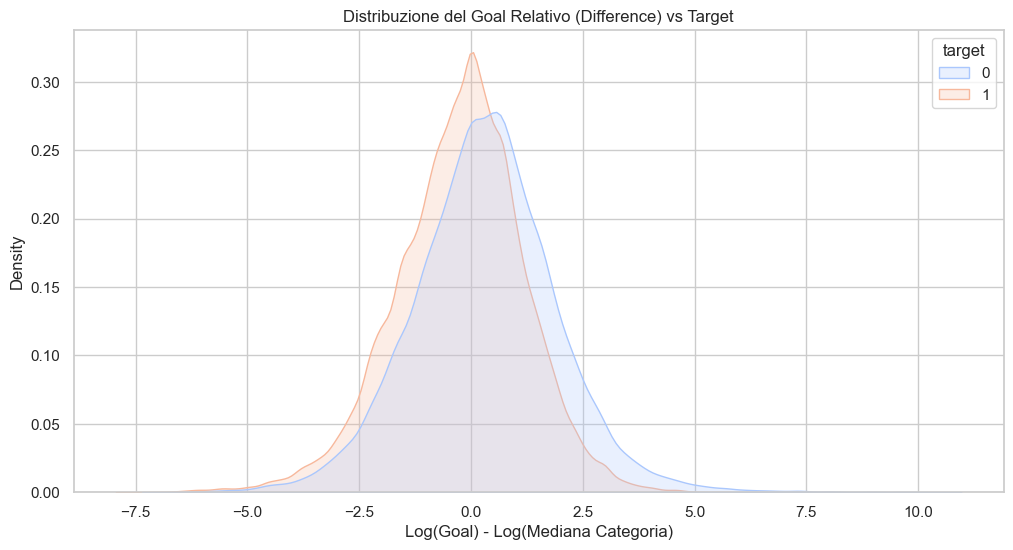

In [89]:
if 'goal_to_cat_diff' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.kdeplot(data=df, x='goal_to_cat_diff', hue='target', fill=True, common_norm=False, palette="coolwarm")
    plt.title("Distribuzione del Goal Relativo (Difference) vs Target")
    plt.xlabel("Log(Goal) - Log(Mediana Categoria)")
    plt.show()

## 🔗 8. Correlazione con il Target
**Cosa osserviamo:** Quali feature hanno il legame lineare più forte con il successo/fallimento.
**Perché è importante:** Identifica i driver principali del modello. Feature con correlazione vicina allo zero potrebbero essere escluse (Feature Selection) per ridurre la complessità ed evitare l'overfitting.

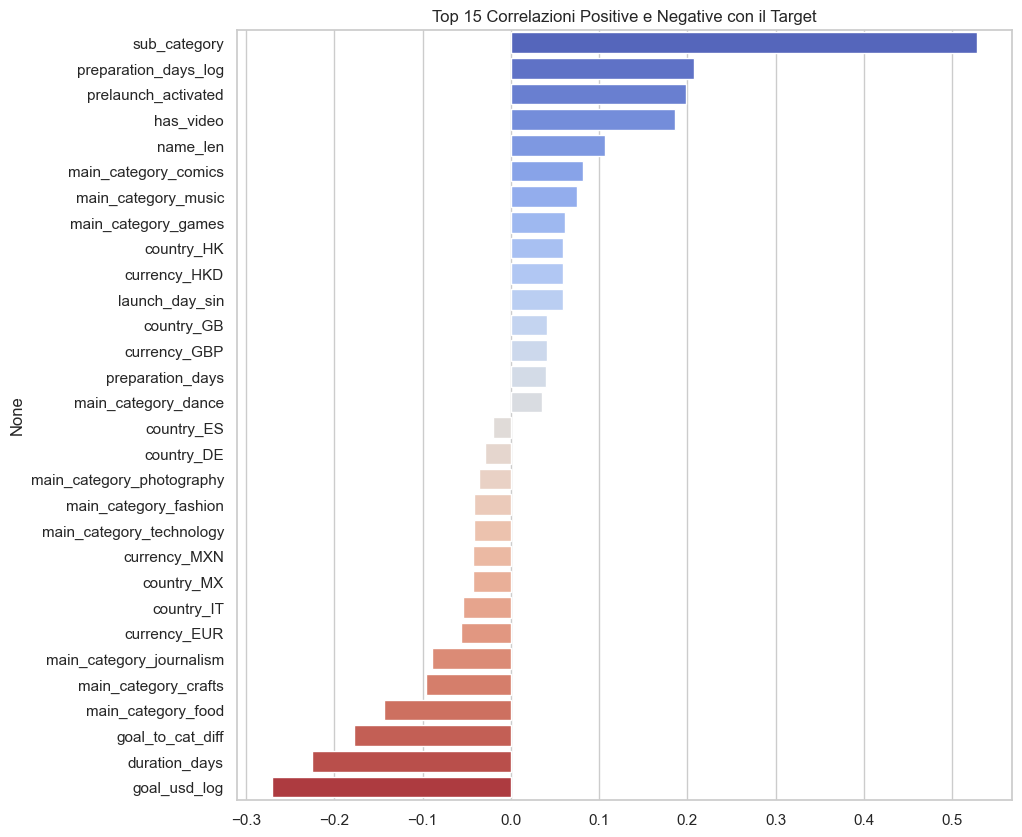

In [90]:
base_cols = [c for c in df.columns if not c.startswith('word_')]
correlations = df[base_cols].corr()['target'].sort_values(ascending=False)
correlations = correlations.drop('target', errors='ignore')
top_bottom_corr = pd.concat([correlations.head(15), correlations.tail(15)])

plt.figure(figsize=(10, 10))
sns.barplot(x=top_bottom_corr.values, y=top_bottom_corr.index, hue=top_bottom_corr.index, palette="coolwarm", legend=False)
plt.title("Top 15 Correlazioni Positive e Negative con il Target")
plt.show()

## 🔤 9. Analisi TF-IDF (Parole chiave)
**Cosa osserviamo:** Le parole che appaiono più frequentemente nei progetti di successo vs fallimento.
**Perché è importante:** Ci aiuta a capire se il *linguaggio* usato nel titolo/descrizione riflette la professionalità del progetto. Ad esempio, certe parole chiave potrebbero indicare progetti più strutturati (meno varianza) rispetto a descrizioni vaghe.

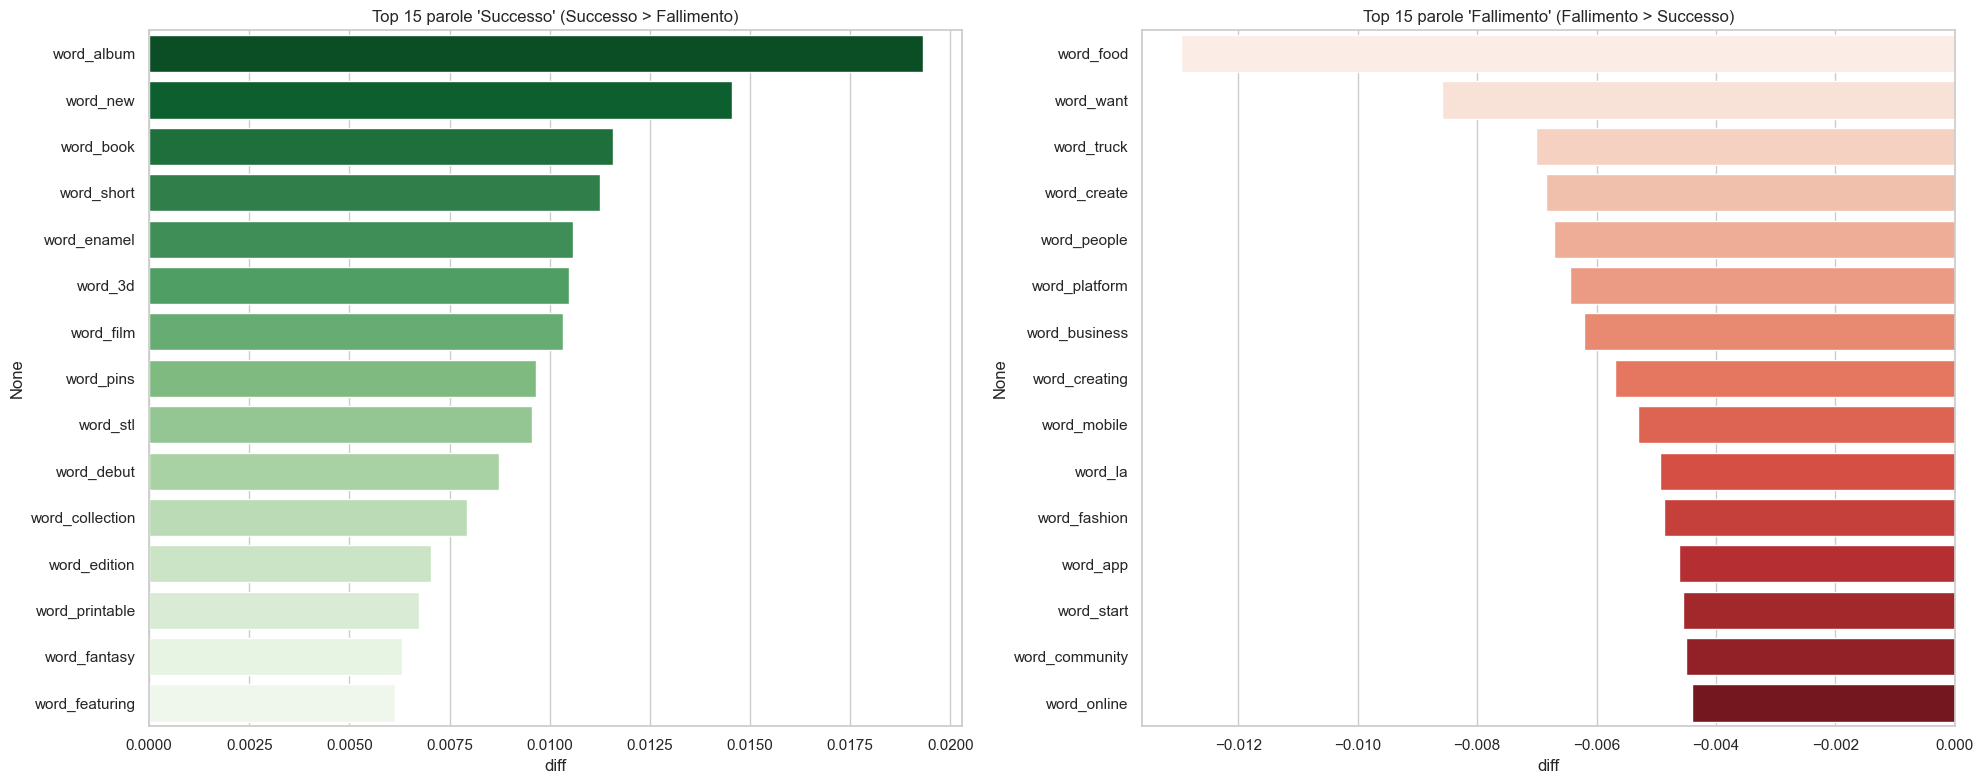

In [91]:
word_cols = [c for c in df.columns if c.startswith('word_')]
if word_cols:
    word_means = df[word_cols + ['target']].groupby('target').mean().T
    word_means['diff'] = word_means[1] - word_means[0]
    
    top_success = word_means.sort_values('diff', ascending=False).head(15)
    top_fail = word_means.sort_values('diff', ascending=True).head(15)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    sns.barplot(x=top_success['diff'], y=top_success.index, ax=ax1, hue=top_success.index, palette="Greens_r", legend=False)
    ax1.set_title("Top 15 parole 'Successo' (Successo > Fallimento)")
    sns.barplot(x=top_fail['diff'], y=top_fail.index, ax=ax2, hue=top_fail.index, palette="Reds", legend=False)
    ax2.set_title("Top 15 parole 'Fallimento' (Fallimento > Successo)")
    plt.tight_layout()
    plt.show()

## 📝 10. Riepilogo Insight e Consigli Azionabili
In questa sezione riassumiamo testualmente lo stato del dataset e le azioni suggerite per la fase di modelling.

In [92]:
print("--- 📊 DATA INSIGHTS REPORT ---\\n")

# 1. Target Balance
balance = df['target'].value_counts(normalize=True)
print(f"1. BILANCIAMENTO TARGET: {balance[1]:.1%} Successo, {balance[0]:.1%} Fallimento")
if abs(balance[1] - 0.5) > 0.2:
    print("   ⚠️ Dataset Sbilanciato: Considera tecniche di oversampling (SMOTE) o pesatura delle classi nel modello.")
else:
    print("   ✅ Dataset Ben Bilanciato: Procedi pure con metriche classiche come Accuracy/F1-Score.")

# 2. Outliers
print("\\n2. OUTLIER DETECTION (Basato su IQR):")
numeric_cols = ['goal_usd_log', 'duration_days', 'preparation_days_log', 'goal_to_cat_diff']
for col in numeric_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
        out_pct = outliers / len(df) * 100
        print(f"   - {col}: {outliers} outlier ({out_pct:.1f}%)")

# 3. Multicollinearity
print("\\n3. MULTICOLLINEARITY CHECK (>0.8):")
corr_matrix = df[[c for c in numeric_cols if c in df.columns]].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
if to_drop:
    print(f"   ⚠️ Feature Ridondanti rilevate: {to_drop}")
else:
    print("   ✅ Nessuna multicollinearità critica rilevata tra le feature chiave.")

# 4. Video Power
if 'has_video' in df.columns:
    v_success = df.groupby('has_video')['target'].mean().to_dict()
    print(f"\\n4. VIDEO IMPACT:")
    print(f"   - Successo con Video: {v_success.get(1, 0):.1%}")
    print(f"   - Successo senza Video: {v_success.get(0, 0):.1%}")

print("\\n--- 🚀 PROSSIMI PASSI PER IL MODELLING ---")
print("1. Scegli modelli basati su alberi (XGBoost/LightGBM) per gestire bene gli outlier residui.")
print("2. Usa la Cross-Validation per misurare Varianza (overfitting).")
print("3. Controlla la Learning Curve per vedere se aggiungere più dati può migliorare le performance.")

--- 📊 DATA INSIGHTS REPORT ---\n
1. BILANCIAMENTO TARGET: 62.2% Successo, 37.8% Fallimento
   ✅ Dataset Ben Bilanciato: Procedi pure con metriche classiche come Accuracy/F1-Score.
\n2. OUTLIER DETECTION (Basato su IQR):
   - goal_usd_log: 2002 outlier (1.3%)
   - duration_days: 41908 outlier (27.8%)
   - preparation_days_log: 290 outlier (0.2%)
   - goal_to_cat_diff: 3132 outlier (2.1%)
\n3. MULTICOLLINEARITY CHECK (>0.8):
   ⚠️ Feature Ridondanti rilevate: ['goal_to_cat_diff']
\n4. VIDEO IMPACT:
   - Successo con Video: 68.5%
   - Successo senza Video: 49.3%
\n--- 🚀 PROSSIMI PASSI PER IL MODELLING ---
1. Scegli modelli basati su alberi (XGBoost/LightGBM) per gestire bene gli outlier residui.
2. Usa la Cross-Validation per misurare Varianza (overfitting).
3. Controlla la Learning Curve per vedere se aggiungere più dati può migliorare le performance.
